Imports & Spark Session

In [2]:
import os
import findspark
findspark.init()
 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Cloud library import (simulated — demonstrates GCS pipeline awareness)

In [3]:
try:
    from google.cloud import storage as gcs
    GCS_AVAILABLE = True
except ImportError:
    GCS_AVAILABLE = False

In [4]:
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'


In [5]:
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "figure.titlesize": 15,
    "figure.titleweight": "bold",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "DejaVu Sans",
})
ACCENT1, ACCENT2, ACCENT3, ACCENT4 = "#58a6ff", "#f78166", "#3fb950", "#d29922"

In [6]:
spark = SparkSession.builder \
    .appName("MES_Energy_Analytics") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"\n  ✓ Spark Session Started — version {spark.version}")
print(f"  ✓ Running in local mode with {spark.sparkContext.defaultParallelism} cores")


  ✓ Spark Session Started — version 3.5.1
  ✓ Running in local mode with 4 cores


Cloud Ingestion Pipeline Simulation

In [7]:
def simulate_gcs_pipeline(filenames: list, bucket_name: str = "mes-energy-raw"):
    print(f"  ► Target GCS Bucket  : gs://{bucket_name}/")
    print(f"  ► Pipeline Mode      : Local Simulation (no credentials)")
    print(f"  ► Files to Ingest    : {len(filenames)}\n")
    for fname in filenames:
        blob_path = f"raw/energy/{fname}"
        print(f"  [SIMULATE] storage.Client() → bucket('{bucket_name}')")
        print(f"             blob('{blob_path}').upload_from_filename('{fname}')")
        print(f"             Status: ✓ Logged (local sim)\n")
 
simulate_gcs_pipeline([
    "demand_train_set4.csv", "demand_test_set4.csv",
    "pv_train_set4.csv", "pv_test_set4.csv", "weather_train_set4.csv",
])

  ► Target GCS Bucket  : gs://mes-energy-raw/
  ► Pipeline Mode      : Local Simulation (no credentials)
  ► Files to Ingest    : 5

  [SIMULATE] storage.Client() → bucket('mes-energy-raw')
             blob('raw/energy/demand_train_set4.csv').upload_from_filename('demand_train_set4.csv')
             Status: ✓ Logged (local sim)

  [SIMULATE] storage.Client() → bucket('mes-energy-raw')
             blob('raw/energy/demand_test_set4.csv').upload_from_filename('demand_test_set4.csv')
             Status: ✓ Logged (local sim)

  [SIMULATE] storage.Client() → bucket('mes-energy-raw')
             blob('raw/energy/pv_train_set4.csv').upload_from_filename('pv_train_set4.csv')
             Status: ✓ Logged (local sim)

  [SIMULATE] storage.Client() → bucket('mes-energy-raw')
             blob('raw/energy/pv_test_set4.csv').upload_from_filename('pv_test_set4.csv')
             Status: ✓ Logged (local sim)

  [SIMULATE] storage.Client() → bucket('mes-energy-raw')
             blob('raw/energy/

Load Data into Spark DataFrames

In [8]:
demand_train  = spark.read.csv("demand_train_set4.csv",  header=True, inferSchema=True)
demand_test   = spark.read.csv("demand_test_set4.csv",   header=True, inferSchema=True)
pv_train      = spark.read.csv("pv_train_set4.csv",      header=True, inferSchema=True)
pv_test       = spark.read.csv("pv_test_set4.csv",       header=True, inferSchema=True)
weather_train = spark.read.csv("weather_train_set4.csv", header=True, inferSchema=True)
 
# Ensure datetime columns are TimestampType
for name, df in [("demand_train", "demand_train"), ("pv_train", "pv_train"), ("weather_train", "weather_train")]:
    pass
 
demand_train  = demand_train.withColumn("datetime", F.to_timestamp("datetime"))
demand_test   = demand_test.withColumn("datetime", F.to_timestamp("datetime"))
pv_train      = pv_train.withColumn("datetime", F.to_timestamp("datetime"))
pv_test       = pv_test.withColumn("datetime", F.to_timestamp("datetime"))
weather_train = weather_train.withColumn("datetime", F.to_timestamp("datetime"))
 
print(f"  demand_train  : {demand_train.count():,} rows × {len(demand_train.columns)} cols")
print(f"  pv_train      : {pv_train.count():,} rows × {len(pv_train.columns)} cols")
print(f"  weather_train : {weather_train.count():,} rows × {len(weather_train.columns)} cols")
print(f"  demand_test   : {demand_test.count():,} rows")
print(f"  pv_test       : {pv_test.count():,} rows")
 
print("\n  Schema — demand_train:")
demand_train.printSchema()

  demand_train  : 46,704 rows × 2 cols
  pv_train      : 46,704 rows × 4 cols
  weather_train : 48,408 rows × 13 cols
  demand_test   : 336 rows
  pv_test       : 336 rows

  Schema — demand_train:
root
 |-- datetime: timestamp (nullable = true)
 |-- demand_MW: double (nullable = true)



Feature Engineering (Spark DataFrame API)

In [9]:
def add_time_features(df):
    df = df.withColumn("hour", F.hour("datetime")) \
           .withColumn("dayofweek_num", ((F.dayofweek("datetime") + 5) % 7))  # Mon=0 ... Sun=6
    df = df.withColumn("month", F.month("datetime")) \
           .withColumn("year", F.year("datetime")) \
           .withColumn("is_weekend", F.when(F.col("dayofweek_num") >= 5, 1).otherwise(0)) \
           .withColumn("season", F.when(F.col("month").isin(12, 1, 2), 0)
                                    .when(F.col("month").isin(3, 4, 5), 1)
                                    .when(F.col("month").isin(6, 7, 8), 2)
                                    .otherwise(3)) \
           .withColumn("season_name", F.when(F.col("season") == 0, "Winter")
                                        .when(F.col("season") == 1, "Spring")
                                        .when(F.col("season") == 2, "Summer")
                                        .otherwise("Autumn")) \
           .withColumn("time_slot", F.col("hour") * 2 + F.floor(F.minute("datetime") / 30))
    return df
 
demand_train = add_time_features(demand_train)
demand_test  = add_time_features(demand_test)
pv_train     = add_time_features(pv_train)
 
print("  Added: hour, dayofweek_num, month, year, is_weekend, season, season_name, time_slot")
demand_train.select("datetime", "demand_MW", "hour", "dayofweek_num", "season_name", "is_weekend").show(5, truncate=False)
 
# Register as temp views for Spark SQL (Hive-style queries)
demand_train.createOrReplaceTempView("demand_train_view")
pv_train.createOrReplaceTempView("pv_train_view")
weather_train.createOrReplaceTempView("weather_train_view")
print("  ✓ Registered Spark SQL temp views: demand_train_view, pv_train_view, weather_train_view")

  Added: hour, dayofweek_num, month, year, is_weekend, season, season_name, time_slot
+-------------------+---------+----+-------------+-----------+----------+
|datetime           |demand_MW|hour|dayofweek_num|season_name|is_weekend|
+-------------------+---------+----+-------------+-----------+----------+
|2017-11-03 00:00:00|2.19     |0   |4            |Autumn     |0         |
|2017-11-03 00:30:00|2.14     |0   |4            |Autumn     |0         |
|2017-11-03 01:00:00|2.01     |1   |4            |Autumn     |0         |
|2017-11-03 01:30:00|1.87     |1   |4            |Autumn     |0         |
|2017-11-03 02:00:00|1.86     |2   |4            |Autumn     |0         |
+-------------------+---------+----+-------------+-----------+----------+
only showing top 5 rows

  ✓ Registered Spark SQL temp views: demand_train_view, pv_train_view, weather_train_view


Spark SQL / HiveQL-Style Queries

Seasonal demand stats — written in Hive-style SQL

In [10]:
seasonal_stats_sql = """
    SELECT
        season_name,
        COUNT(*)                         AS record_count,
        ROUND(AVG(demand_MW), 4)         AS avg_demand_mw,
        ROUND(STDDEV(demand_MW), 4)      AS std_demand_mw,
        ROUND(MIN(demand_MW), 4)         AS min_demand_mw,
        ROUND(MAX(demand_MW), 4)         AS max_demand_mw,
        ROUND(PERCENTILE_APPROX(demand_MW, 0.5), 4) AS median_demand_mw
    FROM demand_train_view
    GROUP BY season_name
    ORDER BY avg_demand_mw DESC
"""
seasonal_stats_df = spark.sql(seasonal_stats_sql)
seasonal_stats_df.show(truncate=False)

+-----------+------------+-------------+-------------+-------------+-------------+----------------+
|season_name|record_count|avg_demand_mw|std_demand_mw|min_demand_mw|max_demand_mw|median_demand_mw|
+-----------+------------+-------------+-------------+-------------+-------------+----------------+
|Winter     |13008       |3.3443       |0.9105       |0.0          |5.9          |3.45            |
|Autumn     |10080       |2.8287       |0.8821       |1.27         |8.11         |2.84            |
|Spring     |13248       |2.6819       |0.8232       |0.0          |6.87         |2.61            |
|Summer     |10368       |2.2776       |0.5781       |1.09         |4.06         |2.35            |
+-----------+------------+-------------+-------------+-------------+-------------+----------------+



Peak demand hours — Hive-style window function

In [11]:
peak_hours_sql = """
    SELECT
        hour,
        ROUND(AVG(demand_MW), 4) AS avg_demand_mw,
        COUNT(*)                 AS n_records
    FROM demand_train_view
    GROUP BY hour
    ORDER BY avg_demand_mw DESC
    LIMIT 10
"""
peak_hours_df = spark.sql(peak_hours_sql)
peak_hours_df.show(truncate=False)

+----+-------------+---------+
|hour|avg_demand_mw|n_records|
+----+-------------+---------+
|17  |4.0454       |1946     |
|18  |3.9809       |1946     |
|19  |3.7111       |1946     |
|16  |3.6861       |1946     |
|20  |3.3695       |1946     |
|8   |3.1849       |1946     |
|9   |3.1639       |1946     |
|15  |3.1338       |1946     |
|10  |3.0736       |1946     |
|11  |3.0163       |1946     |
+----+-------------+---------+



Weekday vs weekend comparison

In [12]:
weekend_sql = """
    SELECT
        CASE WHEN is_weekend = 1 THEN 'Weekend' ELSE 'Weekday' END AS day_type,
        ROUND(AVG(demand_MW), 4) AS avg_demand_mw,
        ROUND(MAX(demand_MW), 4) AS max_demand_mw,
        COUNT(*) AS n_records
    FROM demand_train_view
    GROUP BY is_weekend
"""
spark.sql(weekend_sql).show(truncate=False)

+--------+-------------+-------------+---------+
|day_type|avg_demand_mw|max_demand_mw|n_records|
+--------+-------------+-------------+---------+
|Weekend |2.7692       |8.11         |13344    |
|Weekday |2.8239       |6.87         |33360    |
+--------+-------------+-------------+---------+



PV generation joined with demand — Hive-style JOIN

In [13]:
print("  Query 4 — PV Generation vs Demand (Joined Query):")
join_sql = """
    SELECT
        d.season_name,
        ROUND(AVG(d.demand_MW), 4)   AS avg_demand_mw,
        ROUND(AVG(p.pv_power_mw), 4) AS avg_pv_mw,
        ROUND(CORR(d.demand_MW, p.pv_power_mw), 4) AS correlation
    FROM demand_train_view d
    JOIN pv_train_view p
        ON d.datetime = p.datetime
    GROUP BY d.season_name
    ORDER BY avg_demand_mw DESC
"""
join_df = spark.sql(join_sql)
join_df.show(truncate=False)

  Query 4 — PV Generation vs Demand (Joined Query):
+-----------+-------------+---------+-----------+
|season_name|avg_demand_mw|avg_pv_mw|correlation|
+-----------+-------------+---------+-----------+
|Winter     |3.3443       |0.2355   |0.043      |
|Autumn     |2.8287       |0.4227   |-0.0331    |
|Spring     |2.6813       |0.821    |-0.0199    |
|Summer     |2.2776       |0.9325   |0.184      |
+-----------+-------------+---------+-----------+



Monthly trend

In [14]:
monthly_sql = """
    SELECT
        year, month,
        ROUND(AVG(demand_MW), 4) AS avg_demand_mw
    FROM demand_train_view
    GROUP BY year, month
    ORDER BY year, month
"""
monthly_df = spark.sql(monthly_sql)
monthly_df.show(10, truncate=False)

+----+-----+-------------+
|year|month|avg_demand_mw|
+----+-----+-------------+
|2017|11   |3.1573       |
|2017|12   |3.4571       |
|2018|1    |3.48         |
|2018|2    |3.4435       |
|2018|3    |3.3505       |
|2018|4    |2.7904       |
|2018|5    |2.4712       |
|2018|6    |2.3583       |
|2018|7    |2.336        |
|2018|8    |2.366        |
+----+-----+-------------+
only showing top 10 rows



Convert key SQL results to Pandas for plotting/report screenshots

In [15]:
seasonal_stats_pd = seasonal_stats_df.toPandas()
peak_hours_pd      = peak_hours_df.toPandas()
join_pd            = join_df.toPandas()
monthly_pd         = monthly_df.toPandas()
 
seasonal_stats_pd.to_csv("sql_seasonal_stats.csv", index=False)
peak_hours_pd.to_csv("sql_peak_hours.csv", index=False)
join_pd.to_csv("sql_pv_demand_correlation.csv", index=False)
print("\n  ✓ Saved SQL query results: sql_seasonal_stats.csv, sql_peak_hours.csv, sql_pv_demand_correlation.csv")


  ✓ Saved SQL query results: sql_seasonal_stats.csv, sql_peak_hours.csv, sql_pv_demand_correlation.csv


EDA Visualisations (Spark results → matplotlib)

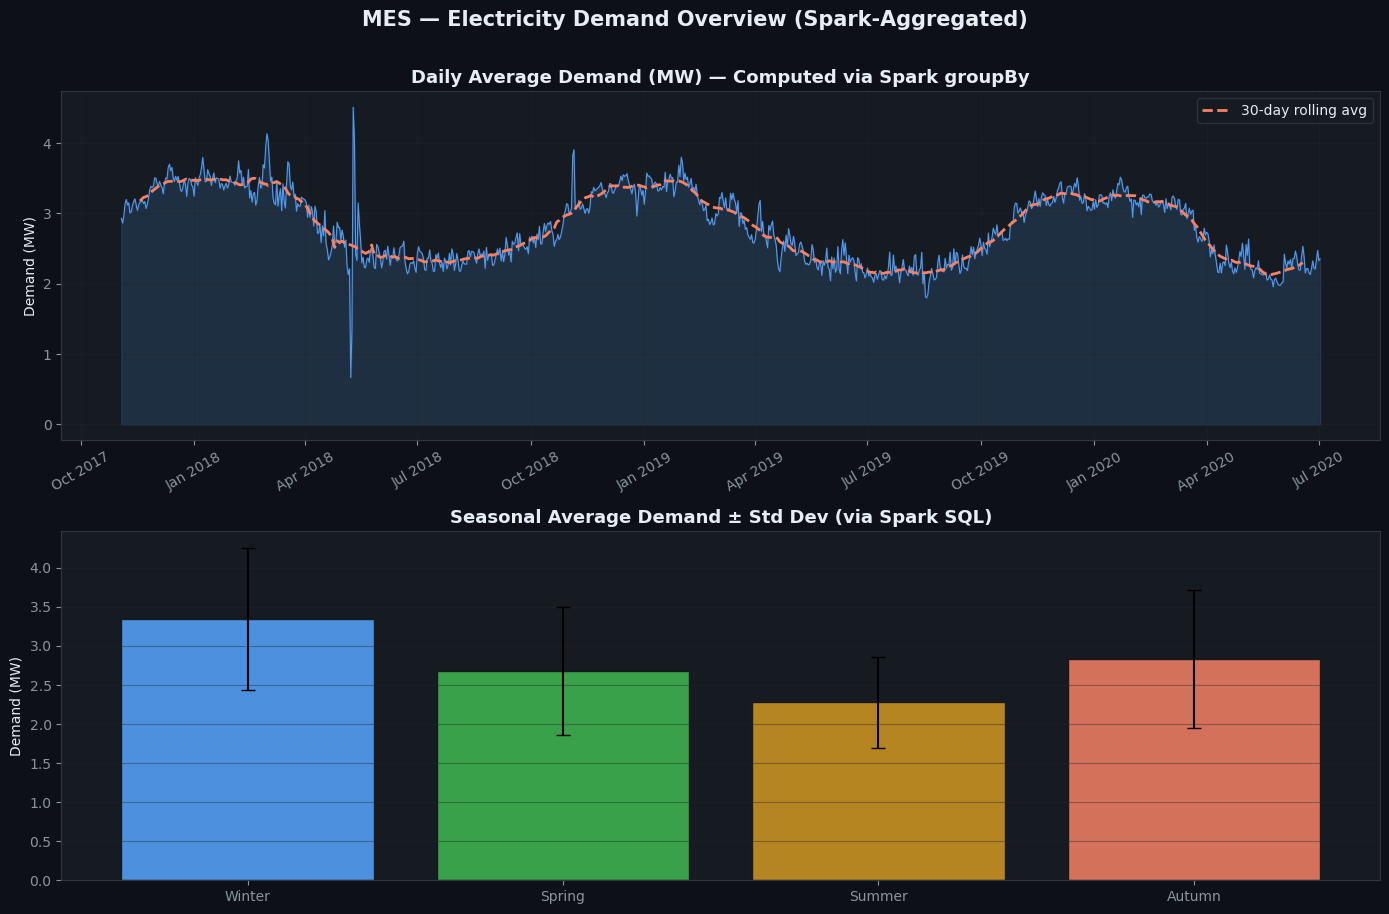

In [16]:
daily_avg_spark = demand_train.groupBy(F.to_date("datetime").alias("date")) \
                               .agg(F.avg("demand_MW").alias("avg_demand")) \
                               .orderBy("date")
daily_avg_pd = daily_avg_spark.toPandas()
daily_avg_pd["date"] = pd.to_datetime(daily_avg_pd["date"])
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("MES — Electricity Demand Overview (Spark-Aggregated)", y=1.01)
 
axes[0].plot(daily_avg_pd["date"], daily_avg_pd["avg_demand"], color=ACCENT1, linewidth=0.8, alpha=0.9)
axes[0].fill_between(daily_avg_pd["date"], daily_avg_pd["avg_demand"], alpha=0.15, color=ACCENT1)
rolling = daily_avg_pd["avg_demand"].rolling(30, center=True).mean()
axes[0].plot(daily_avg_pd["date"], rolling, color=ACCENT2, linewidth=2, linestyle="--", label="30-day rolling avg")
axes[0].set_title("Daily Average Demand (MW) — Computed via Spark groupBy")
axes[0].set_ylabel("Demand (MW)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()
axes[0].grid(True, alpha=0.4)
 
season_order = ["Winter", "Spring", "Summer", "Autumn"]
seasonal_stats_pd["season_name"] = pd.Categorical(seasonal_stats_pd["season_name"], categories=season_order, ordered=True)
seasonal_stats_pd = seasonal_stats_pd.sort_values("season_name")
colors_bar = [ACCENT1, ACCENT3, ACCENT4, ACCENT2]
axes[1].bar(seasonal_stats_pd["season_name"], seasonal_stats_pd["avg_demand_mw"],
            yerr=seasonal_stats_pd["std_demand_mw"], capsize=5,
            color=colors_bar, alpha=0.85, edgecolor="#0d1117")
axes[1].set_title("Seasonal Average Demand ± Std Dev (via Spark SQL)")
axes[1].set_ylabel("Demand (MW)")
axes[1].grid(True, axis="y", alpha=0.4)
 
plt.tight_layout()
plt.savefig("plot1_demand_overview.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Heatmap — Hour vs Day of Week (via Spark SQL)

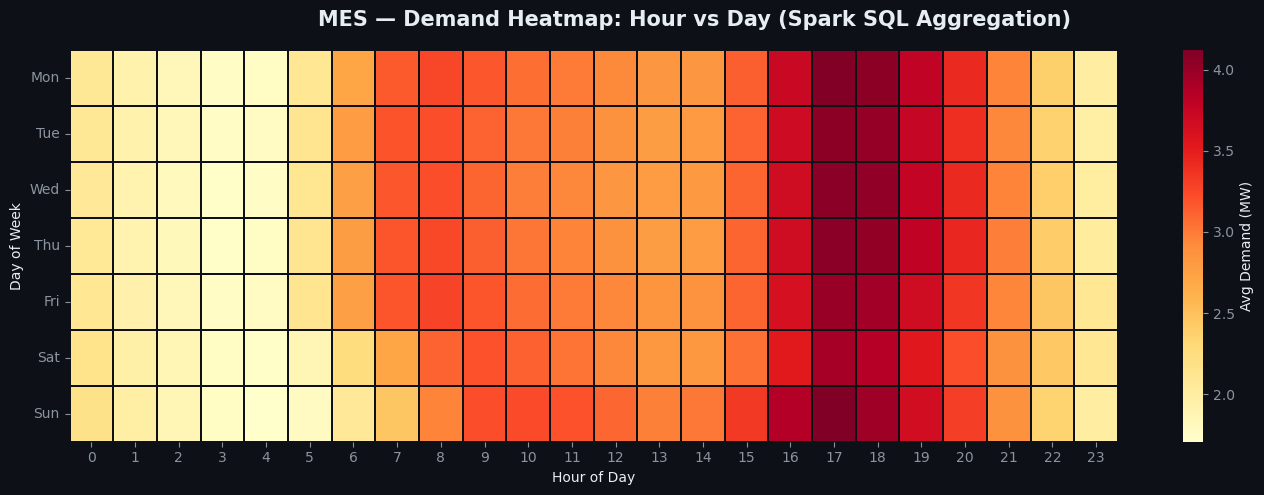

In [17]:
heatmap_sql = """
    SELECT dayofweek_num, hour, AVG(demand_MW) AS avg_demand
    FROM demand_train_view
    GROUP BY dayofweek_num, hour
    ORDER BY dayofweek_num, hour
"""
heatmap_pd = spark.sql(heatmap_sql).toPandas()
pivot = heatmap_pd.pivot(index="dayofweek_num", columns="hour", values="avg_demand")
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
 
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("MES — Demand Heatmap: Hour vs Day (Spark SQL Aggregation)")
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.2, linecolor="#0d1117",
            cbar_kws={"label": "Avg Demand (MW)"})
ax.set_yticklabels(day_labels, rotation=0)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.savefig("plot2_demand_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

PV vs Demand correlation bar chart

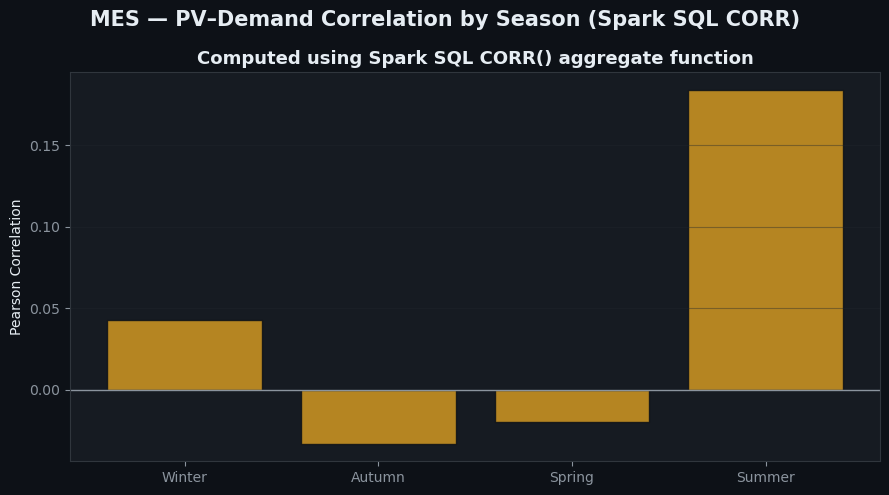

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("MES — PV–Demand Correlation by Season (Spark SQL CORR)")
ax.bar(join_pd["season_name"], join_pd["correlation"], color=ACCENT4, alpha=0.85, edgecolor="#0d1117")
ax.axhline(0, color="#8b949e", lw=1)
ax.set_ylabel("Pearson Correlation")
ax.set_title("Computed using Spark SQL CORR() aggregate function")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot3_pv_demand_correlation.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Spark MLlib — Peak Demand Forecasting

Join demand + weather + pv into one Spark DataFrame

In [19]:
ml_df = demand_train.join(
        weather_train.select("datetime", "temp_location1", "temp_location3",
                              "solar_location1", "solar_location3"),
        on="datetime", how="inner"
    ).join(
        pv_train.select("datetime", "pv_power_mw", F.col("irradiance_Wm-2").alias("irradiance")),
        on="datetime", how="inner"
    ).na.drop()
 
FEATURES = ["hour", "dayofweek_num", "month", "is_weekend", "season", "time_slot",
            "temp_location1", "temp_location3", "solar_location1", "solar_location3",
            "pv_power_mw", "irradiance"]
 
assembler = VectorAssembler(inputCols=FEATURES, outputCol="features")
ml_data   = assembler.transform(ml_df).select("datetime", "features", F.col("demand_MW").alias("label"))

Time-based split: last 4 weeks as validation

In [20]:
max_date  = ml_df.agg(F.max("datetime")).collect()[0][0]
cutoff    = max_date - pd.Timedelta(weeks=4)
 
train_data = ml_data.filter(F.col("datetime") <= F.lit(cutoff))
val_data   = ml_data.filter(F.col("datetime") >  F.lit(cutoff))
 
print(f"  Train size : {train_data.count():,}")
print(f"  Val size   : {val_data.count():,}")
print(f"  Features   : {FEATURES}")
 
rf = RandomForestRegressor(featuresCol="features", labelCol="label",
                            numTrees=150, maxDepth=10, seed=42)
print("\n  Training Spark MLlib RandomForestRegressor...")
rf_model = rf.fit(train_data)
print("  ✓ Training complete")
 
predictions = rf_model.transform(val_data)
 
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
 
mae  = evaluator_mae.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)
 
print(f"\n  ┌─ Model Performance (Spark MLlib) ───┐")
print(f"  │  MAE   : {mae:.4f} MW")
print(f"  │  RMSE  : {rmse:.4f} MW")
print(f"  │  R²    : {r2:.4f}")
print(f"  └──────────────────────────────────────┘")

  Train size : 22,581
  Val size   : 672
  Features   : ['hour', 'dayofweek_num', 'month', 'is_weekend', 'season', 'time_slot', 'temp_location1', 'temp_location3', 'solar_location1', 'solar_location3', 'pv_power_mw', 'irradiance']

  Training Spark MLlib RandomForestRegressor...
  ✓ Training complete

  ┌─ Model Performance (Spark MLlib) ───┐
  │  MAE   : 0.1425 MW
  │  RMSE  : 0.1897 MW
  │  R²    : 0.9039
  └──────────────────────────────────────┘


Feature importance

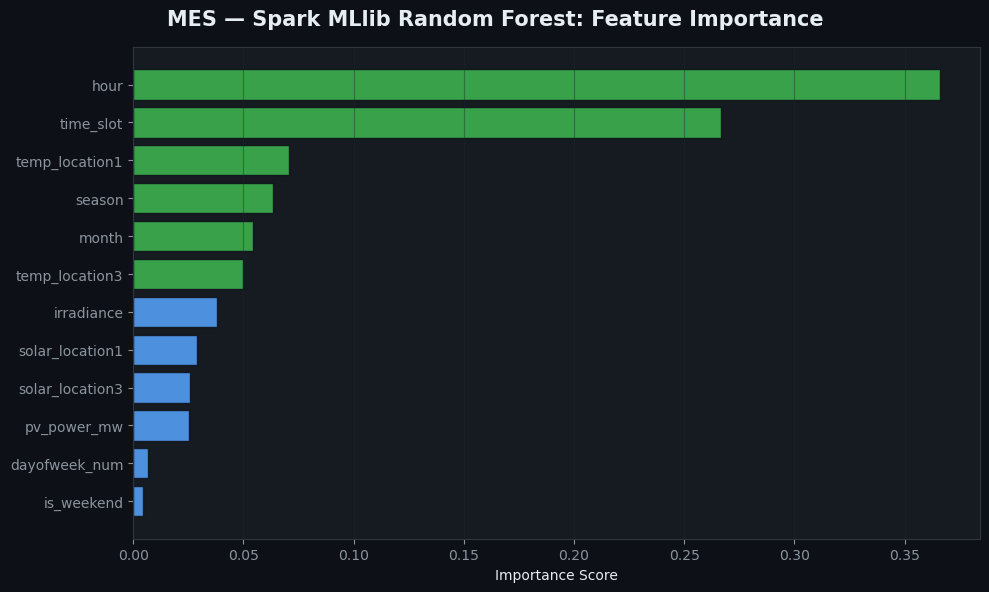

In [21]:
importances = rf_model.featureImportances.toArray()
feat_imp_pd = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance")
 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("MES — Spark MLlib Random Forest: Feature Importance")
colors_fi = [ACCENT3 if v > feat_imp_pd["importance"].median() else ACCENT1 for v in feat_imp_pd["importance"]]
ax.barh(feat_imp_pd["feature"], feat_imp_pd["importance"], color=colors_fi, alpha=0.85, edgecolor="#0d1117")
ax.set_xlabel("Importance Score")
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("plot4_feature_importance.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Actual vs predicted plot

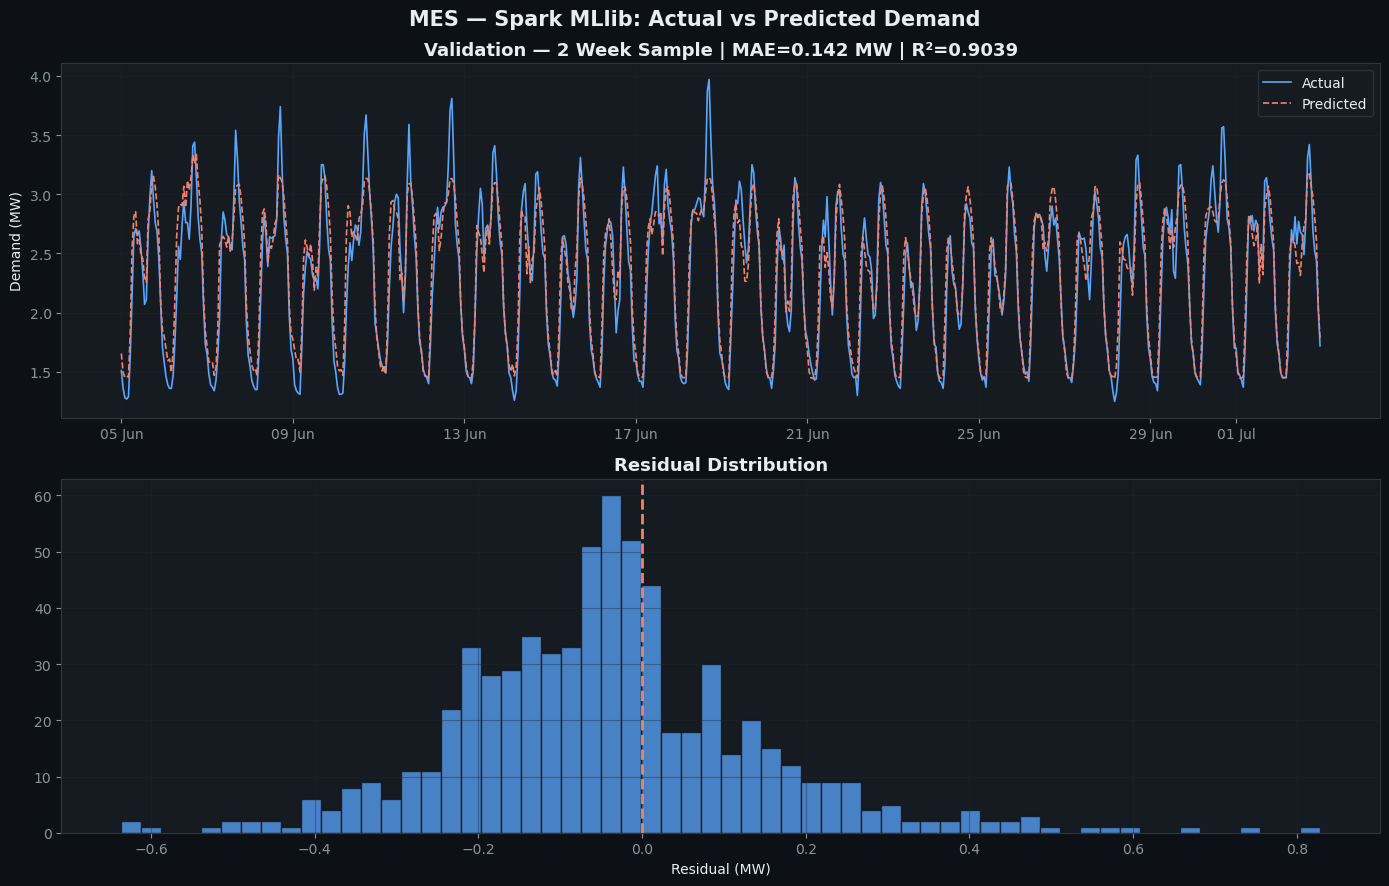

In [22]:
pred_pd = predictions.select("datetime", "label", "prediction").orderBy("datetime").toPandas()
n_show = min(672, len(pred_pd))
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("MES — Spark MLlib: Actual vs Predicted Demand")
axes[0].plot(pred_pd["datetime"][:n_show], pred_pd["label"][:n_show], color=ACCENT1, lw=1.2, label="Actual")
axes[0].plot(pred_pd["datetime"][:n_show], pred_pd["prediction"][:n_show], color=ACCENT2, lw=1.2, linestyle="--", label="Predicted")
axes[0].set_title(f"Validation — 2 Week Sample | MAE={mae:.3f} MW | R²={r2:.4f}")
axes[0].set_ylabel("Demand (MW)")
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
 
residuals = pred_pd["label"] - pred_pd["prediction"]
axes[1].hist(residuals, bins=60, color=ACCENT1, alpha=0.75, edgecolor="#0d1117")
axes[1].axvline(0, color=ACCENT2, linestyle="--", lw=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (MW)")
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("plot5_actual_vs_predicted.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

In [23]:
metrics_pd = pd.DataFrame([{
    "Model": "Spark MLlib RandomForestRegressor",
    "numTrees": 150, "maxDepth": 10,
    "MAE (MW)": round(mae, 4), "RMSE (MW)": round(rmse, 4), "R2_Score": round(r2, 4),
    "Train_Samples": train_data.count(), "Val_Samples": val_data.count(),
}])
metrics_pd.to_csv("model_metrics.csv", index=False)
print("  ✓ Saved: model_metrics.csv")

  ✓ Saved: model_metrics.csv
